# MODELAGENS

### BIBLIOTECAS

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import category_encoders as ce
import shap
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
import shap
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [ ]:
# Se você salvou em CSV
base_sev = pd.read_csv("/content/drive/MyDrive/TCC 2/BANCO DE DADOS/base_sev.csv")

#base_encoded = pd.read_csv("/content/base_encoded.csv")

#X_sev = pd.read_csv("/content/X_sev.csv")


In [ ]:
# Remover a coluna
base_sev = base_sev.drop(columns=["VL_LIMITE_GARANTIA_DEF"])

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
base_glm = base_sev.copy()
base_rlm= base_sev.copy()
base_rf = base_sev.copy()
base_xgb = base_sev.copy()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_sev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190423 entries, 0 to 190422
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NM_MUNICIPIO_PROPRIEDADE   190423 non-null  object 
 1   SG_UF_PROPRIEDADE          190423 non-null  object 
 2   NM_CLASSIF_PRODUTO         190423 non-null  object 
 3   NM_CULTURA_GLOBAL          190423 non-null  object 
 4   NR_AREA_TOTAL              190423 non-null  float64
 5   NR_ANIMAL                  190423 non-null  float64
 6   NR_PRODUTIVIDADE_SEGURADA  190423 non-null  float64
 7   NivelDeCobertura           190423 non-null  float64
 8   EVENTO_PREPONDERANTE       190423 non-null  object 
 9   REGIAO                     190423 non-null  object 
 10  VALOR_INDENIZAÇÃO_DEF      190423 non-null  float64
 11  ANO_2017                   190423 non-null  bool   
 12  ANO_2018                   190423 non-null  bool   
 13  ANO_2019                   19

In [ ]:
base_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190423 entries, 0 to 190422
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   NM_MUNICIPIO_PROPRIEDADE   190423 non-null  float64
 1   SG_UF_PROPRIEDADE          190423 non-null  float64
 2   NM_CLASSIF_PRODUTO         190423 non-null  float64
 3   NM_CULTURA_GLOBAL          190423 non-null  float64
 4   NR_AREA_TOTAL              190423 non-null  float64
 5   NR_ANIMAL                  190423 non-null  float64
 6   NR_PRODUTIVIDADE_SEGURADA  190423 non-null  float64
 7   NivelDeCobertura           190423 non-null  float64
 8   EVENTO_PREPONDERANTE       190423 non-null  float64
 9   REGIAO                     190423 non-null  float64
 10  VL_LIMITE_GARANTIA_DEF     190423 non-null  float64
 11  VALOR_INDENIZAÇÃO_DEF      190423 non-null  float64
 12  ANO_2017                   190423 non-null  bool   
 13  ANO_2018                   19

In [ ]:
X_sev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190423 entries, 0 to 190422
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   const                      190423 non-null  float64
 1   NR_AREA_TOTAL              190423 non-null  float64
 2   NR_ANIMAL                  190423 non-null  float64
 3   NR_PRODUTIVIDADE_SEGURADA  190423 non-null  float64
 4   NivelDeCobertura           190423 non-null  float64
 5   VL_LIMITE_GARANTIA_DEF     190423 non-null  float64
 6   ANO_2017                   190423 non-null  float64
 7   ANO_2018                   190423 non-null  float64
 8   ANO_2019                   190423 non-null  float64
 9   ANO_2020                   190423 non-null  float64
 10  ANO_2021                   190423 non-null  float64
 11  ANO_2022                   190423 non-null  float64
 12  ANO_2023                   190423 non-null  float64
 13  ANO_2024                   19

## GLM GAMA

Embaralha os dados e usa 70% para treino e 30% para teste em cada fold.

Calcula métricas (MAE, RMSE, sMAPE) tanto no treino quanto no teste.

Interpreta os coeficientes na escala exponencial, mostrando o efeito multiplicativo de cada variável.

In [ ]:
# ============================
# 1. Definir variáveis
# ============================
numericas = ['NR_AREA_TOTAL', 'NR_ANIMAL', 'NR_PRODUTIVIDADE_SEGURADA',
             'NivelDeCobertura']

categoricas = ['NM_MUNICIPIO_PROPRIEDADE', 'REGIAO',
               'NM_CLASSIF_PRODUTO', 'NM_CULTURA_GLOBAL',
               'EVENTO_PREPONDERANTE']

# Trabalhar sempre com a mesma base
base_glm = base_glm.copy()

# Target
y_sev = base_glm['VALOR_INDENIZAÇÃO_DEF']
y_sev = y_sev[y_sev > 0]
base_glm = base_glm.loc[y_sev.index].copy()

# ============================
# 2. Função sMAPE segura
# ============================
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# ============================
# 3. Validação cruzada
# ============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_train, rmse_train, smape_train = [], [], []
mae_test, rmse_test, smape_test = [], [], []

for train_idx, test_idx in kf.split(base_glm):

    train_data = base_glm.iloc[train_idx].copy()
    test_data = base_glm.iloc[test_idx].copy()

    # --- Log nas numéricas ---
    for col in ['NR_AREA_TOTAL', 'NR_ANIMAL',
                'NR_PRODUTIVIDADE_SEGURADA']:
        train_data[col] = np.log1p(train_data[col].clip(lower=0))
        test_data[col] = np.log1p(test_data[col].clip(lower=0))

    # --- Escalonamento ---
    scaler = StandardScaler()
    train_data[numericas] = scaler.fit_transform(train_data[numericas])
    test_data[numericas] = scaler.transform(test_data[numericas])

    # --- Target Encoding ---
    encoder = ce.TargetEncoder(cols=categoricas)
    train_encoded = encoder.fit_transform(train_data, train_data['VALOR_INDENIZAÇÃO_DEF'])
    test_encoded = encoder.transform(test_data)

    # --- Montar X ---
    cols_ano_train = [c for c in train_encoded.columns if c.startswith('ANO_')]
    cols_ano_test = [c for c in test_encoded.columns if c.startswith('ANO_')]

    X_train = pd.concat([
        train_encoded[numericas],
        train_encoded[categoricas],
        train_encoded[cols_ano_train]
    ], axis=1)

    X_test = pd.concat([
        test_encoded[numericas],
        test_encoded[categoricas],
        test_encoded[cols_ano_test]
    ], axis=1)

    X_train = sm.add_constant(X_train).astype(float)
    X_test = sm.add_constant(X_test).astype(float)

    # --- Segurança numérica ---
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    y_train = train_data['VALOR_INDENIZAÇÃO_DEF']
    y_test = test_data['VALOR_INDENIZAÇÃO_DEF']

    # ============================
    # Modelo GLM Gamma
    # ============================
    glm_gamma = sm.GLM(
        y_train,
        X_train,
        family=sm.families.Gamma(sm.families.links.Log())
    )

    result_gamma = glm_gamma.fit()

    # Previsões
    y_pred_train = result_gamma.predict(X_train)
    y_pred_test = result_gamma.predict(X_test)

    # Métricas treino
    mae_train.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train.append(smape(y_train, y_pred_train))

    # Métricas teste
    mae_test.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test.append(smape(y_test, y_pred_test))

# ============================
# Resultados
# ============================
print("=== Validação Cruzada ===")
print(f"MAE treino: {np.mean(mae_train):.2f}")
print(f"RMSE treino: {np.mean(rmse_train):.2f}")
print(f"sMAPE treino: {np.mean(smape_train):.2f}%")
print(f"MAE teste: {np.mean(mae_test):.2f}")
print(f"RMSE teste: {np.mean(rmse_test):.2f}")
print(f"sMAPE teste: {np.mean(smape_test):.2f}%")

resultados_gamma = {
    "Modelo": "GLM Gamma",
    "MAE_treino": np.mean(mae_train),
    "RMSE_treino": np.mean(rmse_train),
    "sMAPE_treino": np.mean(smape_train),
    "MAE_teste": np.mean(mae_test),
    "RMSE_teste": np.mean(rmse_test),
    "sMAPE_teste": np.mean(smape_test)
}

print("\n=== Resultados armazenados ===")
print(resultados_gamma)

# ============================
# 4. Modelo final
# ============================

base_final = base_glm.copy()

# Log nas numéricas
for col in ['NR_AREA_TOTAL', 'NR_ANIMAL',
            'NR_PRODUTIVIDADE_SEGURADA']:
    base_final[col] = np.log1p(base_final[col].clip(lower=0))

# Escalonamento
scaler = StandardScaler()
base_final[numericas] = scaler.fit_transform(base_final[numericas])

# Encoding
encoder = ce.TargetEncoder(cols=categoricas)
base_encoded = encoder.fit_transform(base_final, y_sev)

# Montar X final
cols_ano = [c for c in base_encoded.columns if c.startswith('ANO_')]

X_full = pd.concat([
    base_encoded[numericas],
    base_encoded[categoricas],
    base_encoded[cols_ano]
], axis=1)

X_full = sm.add_constant(X_full).astype(float)
X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# Modelo final
glm_gamma_full = sm.GLM(
    y_sev,
    X_full,
    family=sm.families.Gamma(sm.families.links.Log())
)

result_gamma_full = glm_gamma_full.fit()

print("\n=== Resumo do Modelo Final ===")
print(result_gamma_full.summary())

# Interpretação
coef_exp = np.exp(result_gamma_full.params)

print("\n=== Coeficientes (efeito multiplicativo) ===")
print(coef_exp)

# ============================
# 5. Grid Search Tweedie/Gamma
# ============================
param_grid = [
    {"alpha": a, "power": p, "link": l}
    for a in [0.01, 0.1, 1.0]              # regularização
    for p in [1.5, 2.0, 3.0]               # parâmetro de potência
    for l in ["log", "identity"]           # link function
]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_grid = []

for params in param_grid:
    mae_scores = []
    for train_idx, test_idx in kf.split(X_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_sev.iloc[train_idx], y_sev.iloc[test_idx]

        # Definir link
        if params["link"] == "log":
            link_func = sm.families.links.Log()
        else:
            link_func = sm.families.links.Identity()

        # Modelo Tweedie/Gamma
        glm_tweedie = sm.GLM(
            y_train,
            X_train,
            family=sm.families.Tweedie(var_power=params["power"], link=link_func),
            alpha=params["alpha"]
        )
        result = glm_tweedie.fit()
        y_pred = result.predict(X_test)

        mae_scores.append(mean_absolute_error(y_test, y_pred))

    resultados_grid.append({
        "params": params,
        "MAE_CV": np.mean(mae_scores)
    })

# Selecionar melhor configuração
melhor = min(resultados_grid, key=lambda x: x["MAE_CV"])

print("\n=== Melhor configuração Tweedie/Gamma ===")
print(melhor["params"])
print(f"MAE médio (CV): {melhor['MAE_CV']:.2f}")

# ============================
# 6. Avaliar modelo com melhores parâmetros
# ============================

best_params = melhor["params"]

# Definir link
if best_params["link"] == "log":
    link_func = sm.families.links.Log()
else:
    link_func = sm.families.links.Identity()

# Validação cruzada com melhores parâmetros
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_train_best, rmse_train_best, smape_train_best = [], [], []
mae_test_best, rmse_test_best, smape_test_best = [], [], []

for train_idx, test_idx in kf.split(X_full):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_sev.iloc[train_idx], y_sev.iloc[test_idx]

    glm_best = sm.GLM(
        y_train,
        X_train,
        family=sm.families.Tweedie(var_power=best_params["power"], link=link_func),
        alpha=best_params["alpha"]
    )
    result_best = glm_best.fit()

    y_pred_train = result_best.predict(X_train)
    y_pred_test = result_best.predict(X_test)

    # Métricas treino
    mae_train_best.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train_best.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train_best.append(smape(y_train, y_pred_train))

    # Métricas teste
    mae_test_best.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test_best.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test_best.append(smape(y_test, y_pred_test))

print("\n=== Resultados com melhores parâmetros Tweedie/Gamma ===")
print(f"MAE treino: {np.mean(mae_train_best):.2f}")
print(f"RMSE treino: {np.mean(rmse_train_best):.2f}")
print(f"sMAPE treino: {np.mean(smape_train_best):.2f}%")
print(f"MAE teste: {np.mean(mae_test_best):.2f}")
print(f"RMSE teste: {np.mean(rmse_test_best):.2f}")
print(f"sMAPE teste: {np.mean(smape_test_best):.2f}%")


=== Validação Cruzada ===
MAE treino: 59038.12
RMSE treino: 110601.49
sMAPE treino: 70.65%
MAE teste: 59334.68
RMSE teste: 110580.73
sMAPE teste: 70.81%

=== Resultados armazenados ===
{'Modelo': 'GLM Gamma', 'MAE_treino': np.float64(59038.11852887338), 'RMSE_treino': np.float64(110601.49159233601), 'sMAPE_treino': np.float64(70.6494562695765), 'MAE_teste': np.float64(59334.681551150024), 'RMSE_teste': np.float64(110580.73443891082), 'sMAPE_teste': np.float64(70.81213049229125)}

=== Resumo do Modelo Final ===
                   Generalized Linear Model Regression Results                   
Dep. Variable:     VALOR_INDENIZAÇÃO_DEF   No. Observations:               190423
Model:                               GLM   Df Residuals:                   190405
Model Family:                      Gamma   Df Model:                           17
Link Function:                       Log   Scale:                          1.1264
Method:                             IRLS   Log-Likelihood:            -2.3

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1656: RuntimeWarning: invalid value encountered in p


=== Melhor configuração Tweedie/Gamma ===
{'alpha': 0.01, 'power': 1.5, 'link': 'log'}
MAE médio (CV): 57899.82


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['alpha']
  warnings.warn(msg, ValueWarning)



=== Resultados com melhores parâmetros Tweedie/Gamma ===
MAE treino: 57891.23
RMSE treino: 104933.96
sMAPE treino: 70.57%
MAE teste: 57899.82
RMSE teste: 104932.01
sMAPE teste: 70.58%


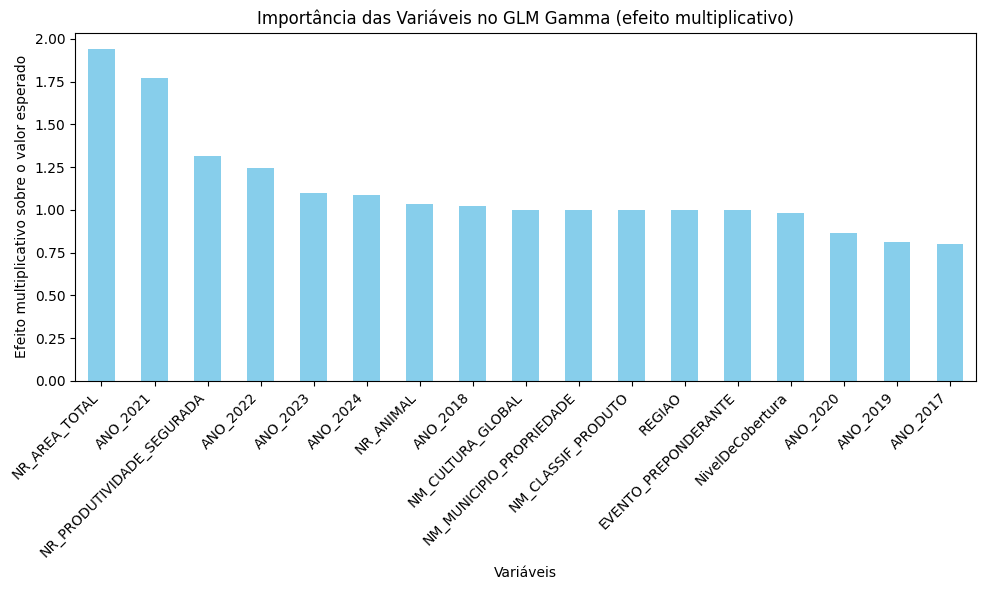

In [ ]:
# Coeficientes exponenciados (efeito multiplicativo)
coef_exp = np.exp(result_gamma_full.params)

# Remover o intercepto para focar nas variáveis
coef_exp = coef_exp.drop('const')

# Ordenar por importância
coef_sorted = coef_exp.sort_values(ascending=False)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
coef_sorted.plot(kind='bar', color='skyblue')
plt.title("Importância das Variáveis no GLM Gamma (efeito multiplicativo)")
plt.ylabel("Efeito multiplicativo sobre o valor esperado")
plt.xlabel("Variáveis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## REGRESSÃO LINEAR

In [ ]:
# ============================
# 1. Definir variáveis
# ============================
numericas = ['NR_AREA_TOTAL', 'NR_ANIMAL', 'NR_PRODUTIVIDADE_SEGURADA',
             'NivelDeCobertura']

categoricas = ['NM_MUNICIPIO_PROPRIEDADE', 'REGIAO',
               'NM_CLASSIF_PRODUTO', 'NM_CULTURA_GLOBAL',
               'EVENTO_PREPONDERANTE']

# Base correta
base_rlm = base_rlm.copy()

# Target
y_sev = base_rlm['VALOR_INDENIZAÇÃO_DEF']
y_sev = y_sev[y_sev > 0]
base_rlm = base_rlm.loc[y_sev.index].copy()

# ============================
# 2. Função sMAPE segura
# ============================
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# ============================
# 3. Validação cruzada
# ============================
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_train, rmse_train, smape_train = [], [], []
mae_test, rmse_test, smape_test = [], [], []

for train_idx, test_idx in kf.split(base_rlm):

    train_data = base_rlm.iloc[train_idx].copy()
    test_data = base_rlm.iloc[test_idx].copy()

    # --- Log nas numéricas ---
    for col in numericas:
        train_data[col] = np.log1p(train_data[col].clip(lower=0))
        test_data[col] = np.log1p(test_data[col].clip(lower=0))

    # --- Escalonamento ---
    scaler = StandardScaler()
    train_data[numericas] = scaler.fit_transform(train_data[numericas])
    test_data[numericas] = scaler.transform(test_data[numericas])

    # --- Target Encoding ---
    encoder = ce.TargetEncoder(cols=categoricas)
    train_encoded = encoder.fit_transform(train_data, train_data['VALOR_INDENIZAÇÃO_DEF'])
    test_encoded = encoder.transform(test_data)

    # --- Montar X ---
    cols_ano_train = [c for c in train_encoded.columns if c.startswith('ANO_')]
    cols_ano_test = [c for c in test_encoded.columns if c.startswith('ANO_')]

    X_train = pd.concat([
        train_encoded[numericas],
        train_encoded[categoricas],
        train_encoded[cols_ano_train]
    ], axis=1)

    X_test = pd.concat([
        test_encoded[numericas],
        test_encoded[categoricas],
        test_encoded[cols_ano_test]
    ], axis=1)

    X_train = sm.add_constant(X_train).astype(float)
    X_test = sm.add_constant(X_test).astype(float)

    # --- Segurança numérica ---
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    # ⚠️ LOG NO TARGET (ESSENCIAL PARA OLS)
    y_train = np.log1p(train_data['VALOR_INDENIZAÇÃO_DEF'])
    y_test = np.log1p(test_data['VALOR_INDENIZAÇÃO_DEF'])

    # ============================
    # Modelo OLS (RLM)
    # ============================
    rlm_model = sm.OLS(y_train, X_train)
    result_rlm = rlm_model.fit()

    # Previsão (voltando para escala original)
    y_pred_train = np.expm1(result_rlm.predict(X_train))
    y_pred_test = np.expm1(result_rlm.predict(X_test))

    # Targets reais (escala original)
    y_train_real = train_data['VALOR_INDENIZAÇÃO_DEF']
    y_test_real = test_data['VALOR_INDENIZAÇÃO_DEF']

    # Métricas treino
    mae_train.append(mean_absolute_error(y_train_real, y_pred_train))
    rmse_train.append(np.sqrt(mean_squared_error(y_train_real, y_pred_train)))
    smape_train.append(smape(y_train_real, y_pred_train))

    # Métricas teste
    mae_test.append(mean_absolute_error(y_test_real, y_pred_test))
    rmse_test.append(np.sqrt(mean_squared_error(y_test_real, y_pred_test)))
    smape_test.append(smape(y_test_real, y_pred_test))

# ============================
# Resultados
# ============================
print("=== Validação Cruzada (RLM) ===")
print(f"MAE treino: {np.mean(mae_train):.2f}")
print(f"RMSE treino: {np.mean(rmse_train):.2f}")
print(f"sMAPE treino: {np.mean(smape_train):.2f}%")
print(f"MAE teste: {np.mean(mae_test):.2f}")
print(f"RMSE teste: {np.mean(rmse_test):.2f}")
print(f"sMAPE teste: {np.mean(smape_test):.2f}%")

# ============================
# 4. Modelo final
# ============================
base_final = base_rlm.copy()

# Log nas numéricas
for col in numericas:
    base_final[col] = np.log1p(base_final[col].clip(lower=0))

# Escalonamento
scaler = StandardScaler()
base_final[numericas] = scaler.fit_transform(base_final[numericas])

# Encoding
encoder = ce.TargetEncoder(cols=categoricas)
base_encoded = encoder.fit_transform(base_final, y_sev)

# X final
cols_ano = [c for c in base_encoded.columns if c.startswith('ANO_')]

X_full = pd.concat([
    base_encoded[numericas],
    base_encoded[categoricas],
    base_encoded[cols_ano]
], axis=1)

X_full = sm.add_constant(X_full).astype(float)
X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# ⚠️ LOG NO TARGET
y_full_log = np.log1p(y_sev)

# Modelo final
rlm_model_full = sm.OLS(y_full_log, X_full)
result_rlm_full = rlm_model_full.fit()

print("\n=== Resumo do Modelo Final (RLM) ===")
print(result_rlm_full.summary())

# ============================
# 5. Coeficientes interpretáveis (%)
# ============================
coef_exp = np.exp(result_rlm_full.params)

print("\n=== Impacto percentual das variáveis ===")
print(coef_exp)

# ============================
# 6. Guardar resultados
# ============================
resultados_rlm = {
    "Modelo": "RLM (log)",
    "MAE_treino": np.mean(mae_train),
    "RMSE_treino": np.mean(rmse_train),
    "sMAPE_treino": np.mean(smape_train),
    "MAE_teste": np.mean(mae_test),
    "RMSE_teste": np.mean(rmse_test),
    "sMAPE_teste": np.mean(smape_test)
}

print("\n=== Resultados armazenados ===")
print(resultados_rlm)

# ============================
# 5. Grid Search para RLM
# ============================
param_grid = [
    {"log_target": True, "log_features": True},
    {"log_target": True, "log_features": False},
    {"log_target": False, "log_features": True},
    {"log_target": False, "log_features": False}
]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_grid = []

for params in param_grid:
    mae_scores = []
    for train_idx, test_idx in kf.split(X_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_sev.iloc[train_idx], y_sev.iloc[test_idx]

        # Target transform
        if params["log_target"]:
            y_train_model = np.log1p(y_train)
        else:
            y_train_model = y_train

        # Modelo OLS
        rlm_model = sm.OLS(y_train_model, X_train)
        result = rlm_model.fit()

        # Previsão
        y_pred = result.predict(X_test)

        # Voltar escala se log_target
        if params["log_target"]:
            y_pred = np.expm1(y_pred)

        mae_scores.append(mean_absolute_error(y_test, y_pred))

    resultados_grid.append({
        "params": params,
        "MAE_CV": np.mean(mae_scores)
    })

# Selecionar melhor configuração
melhor = min(resultados_grid, key=lambda x: x["MAE_CV"])
print("\n=== Melhor configuração RLM ===")
print(melhor["params"])
print(f"MAE médio (CV): {melhor['MAE_CV']:.2f}")

# ============================
# 6. Avaliar modelo com melhores parâmetros
# ============================
best_params = melhor["params"]

mae_train_best, rmse_train_best, smape_train_best = [], [], []
mae_test_best, rmse_test_best, smape_test_best = [], [], []

for train_idx, test_idx in kf.split(X_full):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_sev.iloc[train_idx], y_sev.iloc[test_idx]

    # Target transform
    if best_params["log_target"]:
        y_train_model = np.log1p(y_train)
    else:
        y_train_model = y_train

    rlm_model_best = sm.OLS(y_train_model, X_train)
    result_best = rlm_model_best.fit()

    y_pred_train = result_best.predict(X_train)
    y_pred_test = result_best.predict(X_test)

    if best_params["log_target"]:
        y_pred_train = np.expm1(y_pred_train)
        y_pred_test = np.expm1(y_pred_test)

    # Métricas treino
    mae_train_best.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train_best.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train_best.append(smape(y_train, y_pred_train))

    # Métricas teste
    mae_test_best.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test_best.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test_best.append(smape(y_test, y_pred_test))

print("\n=== Resultados com melhores parâmetros RLM ===")
print(f"MAE treino: {np.mean(mae_train_best):.2f}")
print(f"RMSE treino: {np.mean(rmse_train_best):.2f}")
print(f"sMAPE treino: {np.mean(smape_train_best):.2f}%")
print(f"MAE teste: {np.mean(mae_test_best):.2f}")
print(f"RMSE teste: {np.mean(rmse_test_best):.2f}")
print(f"sMAPE teste: {np.mean(smape_test_best):.2f}%")


=== Validação Cruzada (RLM) ===
MAE treino: 56988.11
RMSE treino: 108153.30
sMAPE treino: 71.10%
MAE teste: 57254.73
RMSE teste: 108706.40
sMAPE teste: 71.24%

=== Resumo do Modelo Final (RLM) ===
                              OLS Regression Results                             
Dep. Variable:     VALOR_INDENIZAÇÃO_DEF   R-squared:                       0.398
Model:                               OLS   Adj. R-squared:                  0.398
Method:                    Least Squares   F-statistic:                     7403.
Date:                   Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                           23:27:31   Log-Likelihood:            -2.9852e+05
No. Observations:                 190423   AIC:                         5.971e+05
Df Residuals:                     190405   BIC:                         5.973e+05
Df Model:                             17                                         
Covariance Type:               nonrobust                         

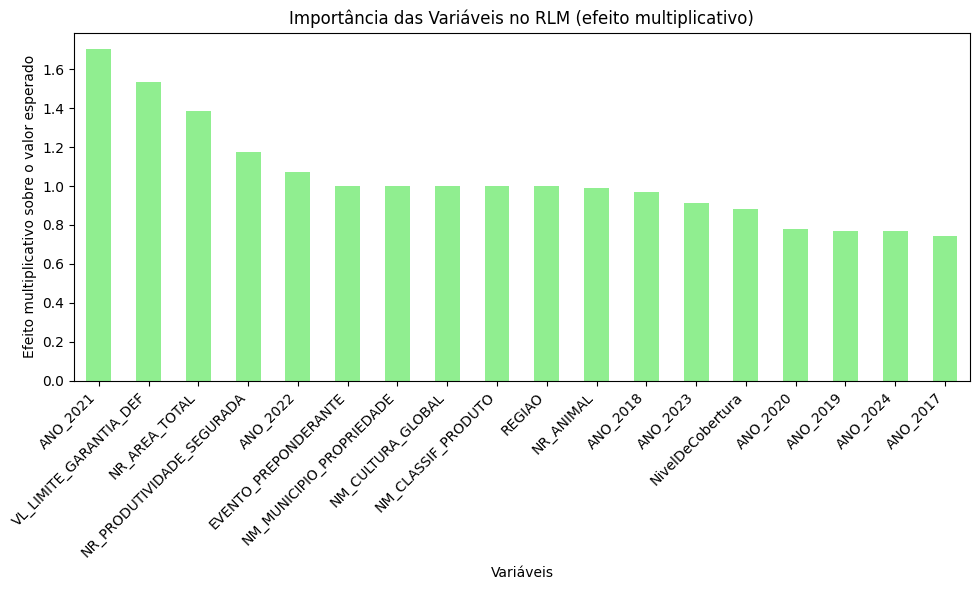

In [ ]:
# Coeficientes exponenciados (impacto percentual/multiplicativo)
coef_exp = np.exp(result_rlm_full.params)

# Remover o intercepto (const) para focar nas variáveis
coef_exp = coef_exp.drop('const')

# Ordenar por importância
coef_sorted = coef_exp.sort_values(ascending=False)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
coef_sorted.plot(kind='bar', color='lightgreen')
plt.title("Importância das Variáveis no RLM (efeito multiplicativo)")
plt.ylabel("Efeito multiplicativo sobre o valor esperado")
plt.xlabel("Variáveis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## RANDOM FOREST

In [ ]:
# ============================
# 1. Definir variáveis
# ============================
numericas = ['NR_AREA_TOTAL', 'NR_ANIMAL', 'NR_PRODUTIVIDADE_SEGURADA',
             'NivelDeCobertura']

categoricas = ['NM_MUNICIPIO_PROPRIEDADE', 'REGIAO',
               'NM_CLASSIF_PRODUTO', 'NM_CULTURA_GLOBAL',
               'EVENTO_PREPONDERANTE']

# Base correta
base_rf = base_rf.copy()

# Target
y_sev = base_rf['VALOR_INDENIZAÇÃO_DEF']
y_sev = y_sev[y_sev > 0]
base_rf = base_rf.loc[y_sev.index].copy()

# ============================
# 2. Função sMAPE segura
# ============================
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# ============================
# 3. Validação cruzada
# ============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_train, rmse_train, smape_train = [], [], []
mae_test, rmse_test, smape_test = [], [], []

for train_idx, test_idx in kf.split(base_rf):

    train_data = base_rf.iloc[train_idx].copy()
    test_data = base_rf.iloc[test_idx].copy()

    # --- Log nas numéricas ---
    for col in numericas:
        train_data[col] = np.log1p(train_data[col].clip(lower=0))
        test_data[col] = np.log1p(test_data[col].clip(lower=0))

    # --- Escalonamento ---
    scaler = StandardScaler()
    train_data[numericas] = scaler.fit_transform(train_data[numericas])
    test_data[numericas] = scaler.transform(test_data[numericas])

    # --- Target Encoding ---
    encoder = ce.TargetEncoder(cols=categoricas)
    train_encoded = encoder.fit_transform(train_data, train_data['VALOR_INDENIZAÇÃO_DEF'])
    test_encoded = encoder.transform(test_data)

    # --- Montar X ---
    cols_ano_train = [c for c in train_encoded.columns if c.startswith('ANO_')]
    cols_ano_test = [c for c in test_encoded.columns if c.startswith('ANO_')]

    X_train = pd.concat([
        train_encoded[numericas],
        train_encoded[categoricas],
        train_encoded[cols_ano_train]
    ], axis=1)

    X_test = pd.concat([
        test_encoded[numericas],
        test_encoded[categoricas],
        test_encoded[cols_ano_test]
    ], axis=1)

    # --- Segurança numérica ---
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    y_train = train_data['VALOR_INDENIZAÇÃO_DEF']
    y_test = test_data['VALOR_INDENIZAÇÃO_DEF']

    # ============================
    # Modelo Random Forest (ajustado)
    # ============================
    rf = RandomForestRegressor(
        n_estimators=200,        # mais árvores para estabilidade
        max_depth=18,            # limitar profundidade
        min_samples_split=10,    # mínimo de amostras para dividir
        min_samples_leaf=5,     # mínimo de amostras por folha
        max_features="sqrt",     # variáveis aleatórias por divisão
        bootstrap=True,          # manter amostragem bootstrap
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred_train = rf.predict(X_train)
    y_pred_test = rf.predict(X_test)

    # Métricas treino
    mae_train.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train.append(smape(y_train, y_pred_train))

    # Métricas teste
    mae_test.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test.append(smape(y_test, y_pred_test))

# ============================
# Resultados
# ============================
print("=== Validação Cruzada (Random Forest Ajustado) ===")
print(f"MAE treino: {np.mean(mae_train):.2f}")
print(f"RMSE treino: {np.mean(rmse_train):.2f}")
print(f"sMAPE treino: {np.mean(smape_train):.2f}%")
print(f"MAE teste: {np.mean(mae_test):.2f}")
print(f"RMSE teste: {np.mean(rmse_test):.2f}")
print(f"sMAPE teste: {np.mean(smape_test):.2f}%")

# ============================
# 4. Guardar resultados
# ============================
resultados_rf = {
    "Modelo": "Random Forest Ajustado",
    "MAE_treino": np.mean(mae_train),
    "RMSE_treino": np.mean(rmse_train),
    "sMAPE_treino": np.mean(smape_train),
    "MAE_teste": np.mean(mae_test),
    "RMSE_teste": np.mean(rmse_test),
    "sMAPE_teste": np.mean(smape_test)
}

print("\n=== Resultados armazenados ===")
print(resultados_rf)

# ============================
# 5. Modelo final (base completa)
# ============================
base_final = base_rf.copy()

# Log nas numéricas
for col in numericas:
    base_final[col] = np.log1p(base_final[col].clip(lower=0))

# Escalonamento
scaler = StandardScaler()
base_final[numericas] = scaler.fit_transform(base_final[numericas])

# Encoding
encoder = ce.TargetEncoder(cols=categoricas)
base_encoded = encoder.fit_transform(base_final, y_sev)

# X final
cols_ano = [c for c in base_encoded.columns if c.startswith('ANO_')]

X_full = pd.concat([
    base_encoded[numericas],
    base_encoded[categoricas],
    base_encoded[cols_ano]
], axis=1)

X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# Modelo final ajustado
rf_model_full = RandomForestRegressor(
    n_estimators=200,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_model_full.fit(X_full, y_sev)

# Função sMAPE já definida
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# Scorer para o GridSearch
smape_scorer = make_scorer(smape, greater_is_better=False)

# Grade de parâmetros
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt']
}

# Modelo base
rf = RandomForestRegressor(
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# GridSearch com validação cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  # pode ajustar o número de folds
    scoring={'MAE': 'neg_mean_absolute_error',
             'RMSE': 'neg_root_mean_squared_error',
             'sMAPE': smape_scorer},
    refit='MAE',
    n_jobs=-1
)

# Ajustar no dataset completo
grid_search.fit(X_full, y_sev)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

# ============================
#  Rodar validação cruzada com os melhores parâmetros
# ============================
best_params = grid_search.best_params_

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_train, rmse_train, smape_train = [], [], []
mae_test, rmse_test, smape_test = [], [], []

for train_idx, test_idx in kf.split(base_rf):

    train_data = base_rf.iloc[train_idx].copy()
    test_data = base_rf.iloc[test_idx].copy()

    # Pré-processamento igual ao anterior
    for col in numericas:
        train_data[col] = np.log1p(train_data[col].clip(lower=0))
        test_data[col] = np.log1p(test_data[col].clip(lower=0))

    scaler = StandardScaler()
    train_data[numericas] = scaler.fit_transform(train_data[numericas])
    test_data[numericas] = scaler.transform(test_data[numericas])

    encoder = ce.TargetEncoder(cols=categoricas)
    train_encoded = encoder.fit_transform(train_data, train_data['VALOR_INDENIZAÇÃO_DEF'])
    test_encoded = encoder.transform(test_data)

    cols_ano_train = [c for c in train_encoded.columns if c.startswith('ANO_')]
    cols_ano_test = [c for c in test_encoded.columns if c.startswith('ANO_')]

    X_train = pd.concat([train_encoded[numericas],
                         train_encoded[categoricas],
                         train_encoded[cols_ano_train]], axis=1)

    X_test = pd.concat([test_encoded[numericas],
                        test_encoded[categoricas],
                        test_encoded[cols_ano_test]], axis=1)

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    y_train = train_data['VALOR_INDENIZAÇÃO_DEF']
    y_test = test_data['VALOR_INDENIZAÇÃO_DEF']

    # Modelo com melhores parâmetros
    rf_best = RandomForestRegressor(
        **best_params,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )

    rf_best.fit(X_train, y_train)

    y_pred_train = rf_best.predict(X_train)
    y_pred_test = rf_best.predict(X_test)

    # Métricas
    mae_train.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train.append(smape(y_train, y_pred_train))

    mae_test.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test.append(smape(y_test, y_pred_test))

# ============================
# Resultados finais
# ============================
print("\n=== Validação Cruzada com melhores parâmetros ===")
print(f"MAE treino: {np.mean(mae_train):.2f}")
print(f"RMSE treino: {np.mean(rmse_train):.2f}")
print(f"sMAPE treino: {np.mean(smape_train):.2f}%")
print(f"MAE teste: {np.mean(mae_test):.2f}")
print(f"RMSE teste: {np.mean(rmse_test):.2f}")
print(f"sMAPE teste: {np.mean(smape_test):.2f}%")



=== Validação Cruzada (Random Forest Ajustado) ===
MAE treino: 47081.23
RMSE treino: 80069.85
sMAPE treino: 62.50%
MAE teste: 51563.64
RMSE teste: 89009.53
sMAPE teste: 65.27%

=== Resultados armazenados ===
{'Modelo': 'Random Forest Ajustado', 'MAE_treino': np.float64(47081.23346418731), 'RMSE_treino': np.float64(80069.8512543921), 'sMAPE_treino': np.float64(62.50162583217782), 'MAE_teste': np.float64(51563.63937873795), 'RMSE_teste': np.float64(89009.52849193157), 'sMAPE_teste': np.float64(65.2727562628807)}


KeyboardInterrupt: 

# ============================
# 5. Gráficos SHAP
# ============================
sample_X = X_full.sample(5000, random_state=42)

explainer = shap.TreeExplainer(rf_model_full)
shap_values = explainer.shap_values(sample_X)

# Gráfico de importância global
shap.summary_plot(shap_values, sample_X, plot_type="bar")

# Gráfico de dispersão
shap.summary_plot(shap_values, sample_X)

## XGBOOST

In [ ]:
# ============================
# 1. Definir variáveis
# ============================
numericas = ['NR_AREA_TOTAL', 'NR_ANIMAL', 'NR_PRODUTIVIDADE_SEGURADA',
             'NivelDeCobertura']
categoricas = ['NM_MUNICIPIO_PROPRIEDADE', 'REGIAO',
               'NM_CLASSIF_PRODUTO', 'NM_CULTURA_GLOBAL',
               'EVENTO_PREPONDERANTE']

y_xgb = base_xgb['VALOR_INDENIZAÇÃO_DEF']
y_xgb = y_xgb[y_xgb > 0]
base_xgb = base_xgb.loc[y_xgb.index]

# ============================
# 2. Validação cruzada KFold
# ============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_train, rmse_train, smape_train = [], [], []
mae_test, rmse_test, smape_test = [], [], []

for train_idx, test_idx in kf.split(base_xgb):
    train_data = base_xgb.iloc[train_idx].copy()
    test_data = base_xgb.iloc[test_idx].copy()

    # Pré-processamento dentro do fold
    for col in numericas:
        train_data[col] = np.log1p(train_data[col].clip(lower=0))
        test_data[col] = np.log1p(test_data[col].clip(lower=0))

    scaler = StandardScaler()
    train_data[numericas] = scaler.fit_transform(train_data[numericas])
    test_data[numericas] = scaler.transform(test_data[numericas])

    encoder = ce.TargetEncoder(cols=categoricas)
    train_encoded = encoder.fit_transform(train_data, train_data['VALOR_INDENIZAÇÃO_DEF'])
    test_encoded = encoder.transform(test_data)

    X_train = pd.concat([
        train_encoded[numericas],
        train_encoded[categoricas],
        train_encoded[[c for c in train_encoded.columns if c.startswith('ANO_')]]
    ], axis=1)

    y_train = train_data['VALOR_INDENIZAÇÃO_DEF']

    X_test = pd.concat([
        test_encoded[numericas],
        test_encoded[categoricas],
        test_encoded[[c for c in test_encoded.columns if c.startswith('ANO_')]]
    ], axis=1)

    y_test = test_data['VALOR_INDENIZAÇÃO_DEF']

    # Modelo XGBoost
    xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    xgb.fit(X_train, y_train)

    y_pred_train = xgb.predict(X_train)
    y_pred_test = xgb.predict(X_test)

    # Métricas treino
    mae_train.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train.append(np.mean(2 * np.abs(y_pred_train - y_train) /
                               (np.abs(y_train) + np.abs(y_pred_train))) * 100)

    # Métricas teste
    mae_test.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test.append(np.mean(2 * np.abs(y_pred_test - y_test) /
                              (np.abs(y_test) + np.abs(y_pred_test))) * 100)

print("=== Resultados da Validação Cruzada (XGBoost) ===")
print(f"MAE treino médio: {np.mean(mae_train):.2f}")
print(f"RMSE treino médio: {np.mean(rmse_train):.2f}")
print(f"sMAPE treino médio: {np.mean(smape_train):.2f}%")
print(f"MAE teste médio: {np.mean(mae_test):.2f}")
print(f"RMSE teste médio: {np.mean(rmse_test):.2f}")
print(f"sMAPE teste médio: {np.mean(smape_test):.2f}%")

# ============================
# 3. Guardar resultados
# ============================
resultados_xgb = {
    "Modelo": "XGBoost",
    "MAE_treino": np.mean(mae_train),
    "RMSE_treino": np.mean(rmse_train),
    "sMAPE_treino": np.mean(smape_train),
    "MAE_teste": np.mean(mae_test),
    "RMSE_teste": np.mean(rmse_test),
    "sMAPE_teste": np.mean(smape_test)
}

print("\n=== Resultados armazenados ===")
print(resultados_xgb)

# ============================
# 4. Ajuste final em toda a base (para SHAP)
# ============================
for col in numericas:
    base_xgb[col] = np.log1p(base_xgb[col].clip(lower=0))

scaler = StandardScaler()
base_xgb[numericas] = scaler.fit_transform(base_xgb[numericas])

encoder = ce.TargetEncoder(cols=categoricas)
base_encoded = encoder.fit_transform(base_xgb, y_xgb)

X_full = pd.concat([
    base_encoded[numericas],
    base_encoded[categoricas],
    base_encoded[[c for c in base_encoded.columns if c.startswith('ANO_')]]
], axis=1)

xgb_model_full = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model_full.fit(X_full, y_xgb)


# Função sMAPE
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# Scorer para o GridSearch
smape_scorer = make_scorer(smape, greater_is_better=False)

# Grade de parâmetros (ajuste conforme necessário)
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Modelo base
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# GridSearch
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring={'MAE': 'neg_mean_absolute_error',
             'RMSE': 'neg_root_mean_squared_error',
             'sMAPE': smape_scorer},
    refit='MAE',
    n_jobs=-1
)

grid_search.fit(X_full, y_xgb)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

# ============================
# Validação cruzada com melhores parâmetros
# ============================
best_params = grid_search.best_params_

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_train, rmse_train, smape_train = [], [], []
mae_test, rmse_test, smape_test = [], [], []

for train_idx, test_idx in kf.split(base_xgb):
    train_data = base_xgb.iloc[train_idx].copy()
    test_data = base_xgb.iloc[test_idx].copy()

    # Pré-processamento igual ao anterior
    for col in numericas:
        train_data[col] = np.log1p(train_data[col].clip(lower=0))
        test_data[col] = np.log1p(test_data[col].clip(lower=0))

    scaler = StandardScaler()
    train_data[numericas] = scaler.fit_transform(train_data[numericas])
    test_data[numericas] = scaler.transform(test_data[numericas])

    encoder = ce.TargetEncoder(cols=categoricas)
    train_encoded = encoder.fit_transform(train_data, train_data['VALOR_INDENIZAÇÃO_DEF'])
    test_encoded = encoder.transform(test_data)

    X_train = pd.concat([
        train_encoded[numericas],
        train_encoded[categoricas],
        train_encoded[[c for c in train_encoded.columns if c.startswith('ANO_')]]
    ], axis=1)

    y_train = train_data['VALOR_INDENIZAÇÃO_DEF']

    X_test = pd.concat([
        test_encoded[numericas],
        test_encoded[categoricas],
        test_encoded[[c for c in test_encoded.columns if c.startswith('ANO_')]]
    ], axis=1)

    y_test = test_data['VALOR_INDENIZAÇÃO_DEF']

    # Modelo com melhores parâmetros
    xgb_best = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    xgb_best.fit(X_train, y_train)

    y_pred_train = xgb_best.predict(X_train)
    y_pred_test = xgb_best.predict(X_test)

    # Métricas treino
    mae_train.append(mean_absolute_error(y_train, y_pred_train))
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    smape_train.append(smape(y_train, y_pred_train))

    # Métricas teste
    mae_test.append(mean_absolute_error(y_test, y_pred_test))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    smape_test.append(smape(y_test, y_pred_test))

print("\n=== Validação Cruzada com melhores parâmetros (XGBoost) ===")
print(f"MAE treino: {np.mean(mae_train):.2f}")
print(f"RMSE treino: {np.mean(rmse_train):.2f}")
print(f"sMAPE treino: {np.mean(smape_train):.2f}%")
print(f"MAE teste: {np.mean(mae_test):.2f}")
print(f"RMSE teste: {np.mean(rmse_test):.2f}")
print(f"sMAPE teste: {np.mean(smape_test):.2f}%")


=== Resultados da Validação Cruzada (XGBoost) ===
MAE treino médio: 47244.91
RMSE treino médio: 79051.77
sMAPE treino médio: 63.38%
MAE teste médio: 51061.18
RMSE teste médio: 88432.12
sMAPE teste médio: 64.95%

=== Resultados armazenados ===
{'Modelo': 'XGBoost', 'MAE_treino': np.float64(47244.91170047338), 'RMSE_treino': np.float64(79051.7699325159), 'sMAPE_treino': np.float64(63.382779346446924), 'MAE_teste': np.float64(51061.178801594164), 'RMSE_teste': np.float64(88432.12197277971), 'sMAPE_teste': np.float64(64.95444089403736)}


KeyboardInterrupt: 

# ============================
# 5. Gráficos SHAP
# ============================
sample_X = X_full.sample(5000, random_state=42)

explainer = shap.TreeExplainer(xgb_model_full)
shap_values = explainer.shap_values(sample_X)

# Gráfico de importância global
shap.summary_plot(shap_values, sample_X, plot_type="bar")

# Gráfico de dispersão
shap.summary_plot(shap_values, sample_X)